In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn optuna --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

COLS = [
    'Unit Number', 'Time (Cycles)', 'Altitude', 'Mach Number', 'TRA',
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30',
    'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc',
    'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32'
]
SENSORS = COLS[5:]
OP_COLS = ['Altitude', 'Mach Number', 'TRA']
N_CONDITIONS = 6

TRIGGER        = 30
RUL_CAP        = 125
BASELINE_N     = 10
TREND_SMOOTH   = 10
TREND_WINDOW   = 20
LAG_PERIODS    = [1, 5, 10, 20, 30]
MIN_CYCLES     = 30
OPTUNA_TRIALS  = 50
OVERPREDICT_ALPHA = 3.0

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Loading

1. Load each FD file separately
2. Drop trailing null columns (26, 27 — artefacts of trailing spaces)
3. Name columns
4. Uniquify unit numbers across datasets
5. Merge into one DataFrame
6. Compute RUL

In [3]:
def load_fd(filename):
    df = pd.read_csv(f'../Data/{filename}', sep=' ', header=None)
    df = df.iloc[:, :26]   # drop trailing null columns 26 & 27
    df.columns = COLS
    return df

# Load all four training datasets
fd001 = load_fd('train_FD001.txt'); fd001['dataset'] = 'FD001'
fd002 = load_fd('train_FD002.txt'); fd002['dataset'] = 'FD002'
fd003 = load_fd('train_FD003.txt'); fd003['dataset'] = 'FD003'
fd004 = load_fd('train_FD004.txt'); fd004['dataset'] = 'FD004'

# Uniquify unit numbers so they don't overlap across datasets
fd002['Unit Number'] += fd001['Unit Number'].max()
fd003['Unit Number'] += fd002['Unit Number'].max()
fd004['Unit Number'] += fd003['Unit Number'].max()

df_all = pd.concat([fd001, fd002, fd003, fd004], ignore_index=True)

# RUL = cycles until failure
df_all['Fail Time'] = df_all.groupby('Unit Number')['Time (Cycles)'].transform('max')
df_all['RUL']       = df_all['Fail Time'] - df_all['Time (Cycles)']

print(f"Engines : {df_all['Unit Number'].nunique()}")
print(f"Rows    : {len(df_all):,}")
print(f"RUL range: {df_all['RUL'].min()} – {df_all['RUL'].max()}")

Engines : 709
Rows    : 160,359
RUL range: 0 – 542


## Operational Condition Clustering

The scaler and KMeans are fit on training engines only, then applied to val/test to avoid leakage.

Condition counts:
Condition
0    17213
1    62633
2    17141
3    28853
4    17320
5    17199
Name: count, dtype: int64


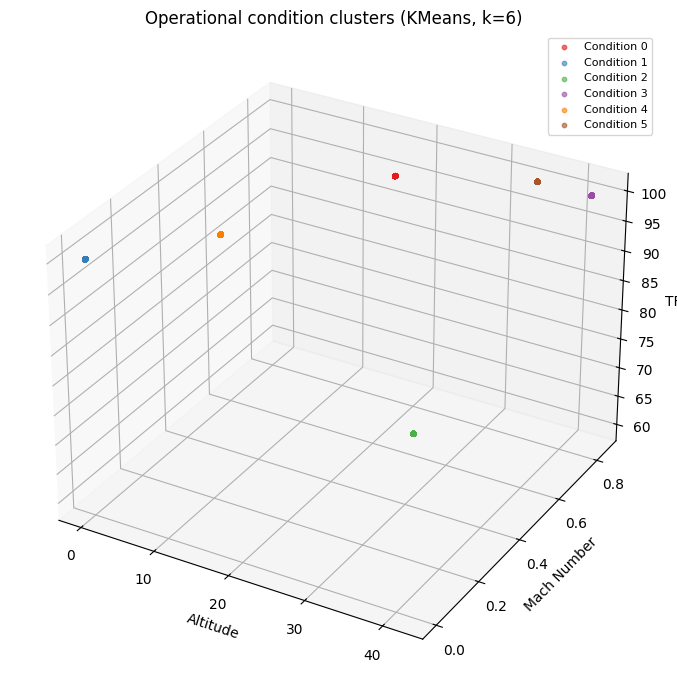

In [4]:
# Fit scaler and KMeans on all data for now (before the split).
# Operational parameters are fixed physical states — not engine-health dependent —
# so all 6 conditions appear in every subset; fitting on all vs train-only gives
# identical cluster assignments.
op_scaler = StandardScaler()
op_scaled = op_scaler.fit_transform(df_all[OP_COLS])

km = KMeans(n_clusters=N_CONDITIONS, random_state=42, n_init=10)
df_all['Condition'] = km.fit_predict(op_scaled)

print(f"Condition counts:")
print(df_all['Condition'].value_counts().sort_index())

# Quick 3D visualisation
from mpl_toolkits.mplot3d import Axes3D
colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628']
fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')
sample = df_all.sample(10000, random_state=42)
for c in range(N_CONDITIONS):
    m = sample['Condition'] == c
    ax.scatter(sample.loc[m,'Altitude'], sample.loc[m,'Mach Number'], sample.loc[m,'TRA'],
               c=colors[c], label=f'Condition {c}', s=10, alpha=0.6)
ax.set(xlabel='Altitude', ylabel='Mach Number', zlabel='TRA',
       title='Operational condition clusters (KMeans, k=6)')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Feature Engineering

| Group | # | What it captures |
|---|---|---|
| Raw sensors | 21 | Absolute readings |
| `_dev` | 21 | Drift from early-life baseline |
| `_trend` | 21 | Local rate of change |
| `_hslope` | 21 | Average drift rate since cycle 1 |
| Ratios | 5 | Thermodynamic efficiency |
| `_lagN` | 105 | Raw readings N cycles ago |
| `Condition` | 1 | Operational condition cluster (0–5) |
| **Total** | **195** | |

In [5]:
# ── Baseline deviation ────────────────────────────────────────────────────────
DEV_COLS = [f'{s}_dev' for s in SENSORS]
parts = []
for unit, eng in df_all.groupby('Unit Number'):
    eng = eng.sort_values('Time (Cycles)').copy()
    n = len(eng)
    cumean = eng[SENSORS].expanding(min_periods=1).mean()
    frozen = cumean.iloc[min(BASELINE_N - 1, n - 1)]
    new = {}
    for s in SENSORS:
        bl = np.where(np.arange(n) < BASELINE_N, cumean[s].values, frozen[s])
        new[f'{s}_dev'] = eng[s].values - bl
    parts.append(pd.DataFrame(new, index=eng.index))
feat = pd.concat(parts)
for col in DEV_COLS: df_all[col] = feat[col]
print(f'_dev   : {len(DEV_COLS)} features')

_dev   : 21 features


In [6]:
# ── Local trend ───────────────────────────────────────────────────────────────
TREND_COLS = [f'{s}_trend' for s in SENSORS]
parts = []
for unit, eng in df_all.groupby('Unit Number'):
    eng = eng.sort_values('Time (Cycles)').copy()
    new = {f'{s}_trend': eng[s].rolling(TREND_SMOOTH, min_periods=1).mean()
                                .diff(TREND_WINDOW).fillna(0).values / TREND_WINDOW
           for s in SENSORS}
    parts.append(pd.DataFrame(new, index=eng.index))
feat = pd.concat(parts)
for col in TREND_COLS: df_all[col] = feat[col]
print(f'_trend : {len(TREND_COLS)} features')

_trend : 21 features


In [7]:
# ── History slope ─────────────────────────────────────────────────────────────
HSLOPE_COLS = [f'{s}_hslope' for s in SENSORS]
parts = []
for unit, eng in df_all.groupby('Unit Number'):
    eng = eng.sort_values('Time (Cycles)').copy()
    new = {}
    for s in SENSORS:
        hist_mean = eng[s].expanding(min_periods=1).mean()
        new[f'{s}_hslope'] = (hist_mean.values - eng[s].iloc[0]) / np.maximum(eng['Time (Cycles)'].values, 1)
    parts.append(pd.DataFrame(new, index=eng.index))
feat = pd.concat(parts)
for col in HSLOPE_COLS: df_all[col] = feat[col]
print(f'_hslope: {len(HSLOPE_COLS)} features')

_hslope: 21 features


In [8]:
# ── Sensor ratios ─────────────────────────────────────────────────────────────
RATIO_PAIRS = [('T30','T24'),('T50','T30'),('P30','P2'),('P30','P15'),('NRf','NRc')]
RATIO_COLS  = [f'{n}_over_{d}' for n, d in RATIO_PAIRS]
for num, den in RATIO_PAIRS:
    df_all[f'{num}_over_{den}'] = df_all[num] / df_all[den].clip(lower=1e-6)
print(f'ratios : {len(RATIO_COLS)} features')

ratios : 5 features


In [9]:
# ── Lag features ──────────────────────────────────────────────────────────────
LAG_COLS = [f'{s}_lag{lag}' for s in SENSORS for lag in LAG_PERIODS]
parts = []
for unit, eng in df_all.groupby('Unit Number'):
    eng = eng.sort_values('Time (Cycles)').copy()
    new = {}
    for lag in LAG_PERIODS:
        for s in SENSORS:
            new[f'{s}_lag{lag}'] = eng[s].shift(lag).fillna(eng[s].iloc[0]).values
    parts.append(pd.DataFrame(new, index=eng.index))
feat = pd.concat(parts)
for col in LAG_COLS: df_all[col] = feat[col]
print(f'_lagN  : {len(LAG_COLS)} features ({len(LAG_PERIODS)} periods × {len(SENSORS)} sensors)')

_lagN  : 105 features (5 periods × 21 sensors)


In [10]:
LAGDIFF_COLS = []  # removed

In [11]:
# ── Assemble feature columns ──────────────────────────────────────────────────
FEATURE_COLS = (
    SENSORS + DEV_COLS + TREND_COLS + HSLOPE_COLS +
    RATIO_COLS + LAG_COLS + ['Condition']
)

print(f'Feature breakdown:')
print(f'  Raw sensors     : {len(SENSORS)}')
print(f'  Baseline dev    : {len(DEV_COLS)}')
print(f'  Local trend     : {len(TREND_COLS)}')
print(f'  History slope   : {len(HSLOPE_COLS)}')
print(f'  Ratios          : {len(RATIO_COLS)}')
print(f'  Lag features    : {len(LAG_COLS)}')
print(f'  Condition       : 1')
print(f'  {"─"*22}')
print(f'  TOTAL           : {len(FEATURE_COLS)}')

assert not df_all[FEATURE_COLS].isnull().any().any(), 'NaN in features!'
print('\nNaN check: clean. ✓')

Feature breakdown:
  Raw sensors     : 21
  Baseline dev    : 21
  Local trend     : 21
  History slope   : 21
  Ratios          : 5
  Lag features    : 105
  Condition       : 1
  ──────────────────────
  TOTAL           : 195

NaN check: clean. ✓


## Train / Val / Test Split

- **Test (20%)** — held out completely, used only for final evaluation and deployment simulation
- **Val (10% of remainder)** — early stopping only, never used for evaluation
- **Train (remaining ~72%)** — model learns from these

In [12]:
engines = df_all[['Unit Number', 'dataset']].drop_duplicates()

train_val_engines, test_engines = train_test_split(
    engines, test_size=0.2, random_state=42, stratify=engines['dataset']
)
train_engines, val_engines = train_test_split(
    train_val_engines, test_size=0.1, random_state=42, stratify=train_val_engines['dataset']
)

train_df = df_all[df_all['Unit Number'].isin(train_engines['Unit Number'])].copy()
val_df   = df_all[df_all['Unit Number'].isin(val_engines['Unit Number'])].copy()
test_df  = df_all[df_all['Unit Number'].isin(test_engines['Unit Number'])].copy()

y_train = train_df['RUL'].clip(upper=RUL_CAP).values
y_val   = val_df['RUL'].clip(upper=RUL_CAP).values
y_test  = test_df['RUL'].clip(upper=RUL_CAP).values

print(f'Train : {train_df["Unit Number"].nunique()} engines | {len(train_df):,} rows')
print(f'Val   : {val_df["Unit Number"].nunique()} engines | {len(val_df):,} rows   (early stopping only)')
print(f'Test  : {test_df["Unit Number"].nunique()} engines | {len(test_df):,} rows   (never seen during training)')

Train : 510 engines | 115,806 rows
Val   : 57 engines | 12,236 rows   (early stopping only)
Test  : 142 engines | 32,317 rows   (never seen during training)


## Feature Overview

In [13]:
groups = [
    ('Raw sensors',     SENSORS,      'Absolute sensor readings'),
    ('Baseline dev',    DEV_COLS,     'Drift from early-life average (first 10 cycles)'),
    ('Local trend',     TREND_COLS,   'Rate of change over recent window'),
    ('History slope',   HSLOPE_COLS,  'Average drift rate since cycle 1'),
    ('Ratios',          RATIO_COLS,   'Thermodynamic efficiency ratios'),
    ('Lag features',    LAG_COLS,     'Raw sensor readings N cycles ago (N=1,5,10,20,30)'),
    ('Condition',       ['Condition'],'KMeans operational condition cluster (0–5)'),
]

header = f"{'Group':<18} {'Count':>5}   {'Example features':<45} {'What it captures'}"
print(header)
print('─' * len(header))
total = 0
for name, cols, desc in groups:
    examples = ', '.join(cols[:3]) + ('…' if len(cols) > 3 else '')
    print(f'{name:<18} {len(cols):>5}   {examples:<45} {desc}')
    total += len(cols)
print('─' * len(header))
print(f'{"TOTAL":<18} {total:>5}')
print(f'\nAll {total} features stored in FEATURE_COLS.')

Group              Count   Example features                              What it captures
─────────────────────────────────────────────────────────────────────────────────────────
Raw sensors           21   T2, T24, T30…                                 Absolute sensor readings
Baseline dev          21   T2_dev, T24_dev, T30_dev…                     Drift from early-life average (first 10 cycles)
Local trend           21   T2_trend, T24_trend, T30_trend…               Rate of change over recent window
History slope         21   T2_hslope, T24_hslope, T30_hslope…            Average drift rate since cycle 1
Ratios                 5   T30_over_T24, T50_over_T30, P30_over_P2…      Thermodynamic efficiency ratios
Lag features         105   T2_lag1, T2_lag5, T2_lag10…                   Raw sensor readings N cycles ago (N=1,5,10,20,30)
Condition              1   Condition                                     KMeans operational condition cluster (0–5)
────────────────────────────────────────────

### Feature group explanations

---

**Raw sensors** — the 21 sensor channels recorded each cycle exactly as provided by the dataset (temperatures, pressures, shaft speeds, fuel flows, etc.). These give the model the absolute physical state of the engine at each point in time.

---

**Baseline deviation (`_dev`)** — how much each sensor has drifted from the engine's own early-life behaviour.

For each engine we compute a running mean of the sensor over the first 10 cycles (`BASELINE_N = 10`). After cycle 10 that mean is frozen as the "healthy baseline". The feature is then:

```
dev = sensor_value − baseline
```

An engine with a healthy sensor reads near 0. As wear accumulates the sensor drifts and `_dev` grows, giving the model a direct signal of degradation that is not confounded by between-engine manufacturing differences.

---

**Local trend (`_trend`)** — the recent rate of change of each sensor, smoothed to reduce noise.

```
trend = ( smooth(sensor, window=10) at cycle t
        − smooth(sensor, window=10) at cycle t−20 ) / 20
```

This captures whether a sensor is currently accelerating upward or downward over the last ~20 cycles (`TREND_WINDOW = 20`). A steepening trend often precedes failure even before the absolute value is alarming.

---

**History slope (`_hslope`)** — the average drift rate of each sensor since the very first cycle.

```
hslope = ( cumulative_mean(sensor) − sensor_at_cycle_1 ) / time
```

Where `_dev` asks "how far has this sensor moved from healthy?", `_hslope` asks "how fast has it been moving on average over its whole life?". Together the two features give the model both the magnitude and the pace of degradation.

---

**Ratios** — five thermodynamic ratios between physically related sensor pairs:

| Feature | Numerator / Denominator | What it captures |
|---|---|---|
| `T30_over_T24` | Compressor outlet / inlet temp | Compressor efficiency |
| `T50_over_T30` | Turbine outlet / compressor outlet | Turbine efficiency |
| `P30_over_P2` | High-pressure / fan inlet pressure | Overall pressure ratio |
| `P30_over_P15` | High-pressure / bypass pressure | Bleed valve health |
| `NRf_over_NRc` | Fan corrected speed / core corrected speed | Shaft coupling |

Ratios are less sensitive to operating-point shifts (altitude, throttle) than raw readings, so they expose efficiency degradation more directly.

---

**Lag features (`_lagN`)** — the raw sensor value recorded N cycles in the past, for N ∈ {1, 5, 10, 20, 30}.

```
lag1  = sensor value 1 cycle ago
lag5  = sensor value 5 cycles ago
...
lag30 = sensor value 30 cycles ago
```

XGBoost has no memory between rows, so lags encode the recent history explicitly. The five time horizons let the model compare short-term fluctuations (lag1 vs lag5) against longer-term evolution (lag10 vs lag30).

---

**Condition** — a single integer (0–5) identifying the operational regime at each cycle, produced by KMeans clustering on the three operating parameters (Altitude, Mach Number, TRA).

The CMAPSS dataset contains engines run under multiple fixed flight conditions. Without this label, a change in sensor reading could look like degradation when it is actually just a change in throttle setting. Knowing the condition lets the model compare readings only within the same operating regime.

## Hyperparameter Tuning (Optuna)

20% of training data, 2-fold cross-validation, asymmetric RMSE objective.  
`BEST_PARAMS` is passed directly to the XGBoost model in the next section.

In [14]:
def asymmetric_mse(y_true, y_pred):
    r    = y_pred - y_true
    grad = np.where(r > 0, OVERPREDICT_ALPHA * r, r)
    hess = np.where(r > 0, OVERPREDICT_ALPHA * np.ones_like(r), np.ones_like(r))
    return grad, hess


def rul_score(y_true, y_pred):
    """Official CMAPSS benchmark scorer. Late predictions penalised more (exp/10 vs exp/13)."""
    diff = y_pred - y_true
    return float(np.abs(np.sum(np.where(diff < 0, np.exp(-diff / 13) - 1, np.exp(diff / 10) - 1))))


def optuna_objective(trial, X, y):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators',      100, 300),
        max_depth         = trial.suggest_int('max_depth',           3,   8),
        learning_rate     = trial.suggest_float('learning_rate',   0.01, 0.20, log=True),
        subsample         = trial.suggest_float('subsample',        0.5,  1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5,  1.0),
        min_child_weight  = trial.suggest_int('min_child_weight',    1,  25),
        gamma             = trial.suggest_float('gamma',             0,   5.0),
        reg_alpha         = trial.suggest_float('reg_alpha',         0,   3.0),
        reg_lambda        = trial.suggest_float('reg_lambda',       0.5,  6.0),
        objective         = asymmetric_mse,
        eval_metric       = 'rmse',
        random_state      = 42,
        n_jobs            = -1,
    )
    kf     = KFold(n_splits=2, shuffle=True, random_state=42)
    scaler = StandardScaler()
    scores = []
    for tr_idx, vl_idx in kf.split(X):
        X_tr, X_vl = X[tr_idx], X[vl_idx]
        y_tr, y_vl = y[tr_idx], y[vl_idx]
        X_tr = scaler.fit_transform(X_tr)
        X_vl = scaler.transform(X_vl)
        m = xgb.XGBRegressor(**params)
        m.fit(X_tr, y_tr, verbose=False)
        scores.append(rul_score(y_vl, m.predict(X_vl)))
    return float(np.mean(scores))


# Use 20% of training data for speed
rng     = np.random.default_rng(42)
n_tune  = int(0.20 * len(train_df))
idx     = rng.choice(len(train_df), n_tune, replace=False)
X_tune  = train_df[FEATURE_COLS].values[idx]
y_tune  = y_train[idx]

study = optuna.create_study(direction='minimize',
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(lambda trial: optuna_objective(trial, X_tune, y_tune),
               n_trials=OPTUNA_TRIALS, show_progress_bar=True)

BEST_PARAMS = study.best_params
print(f'\nBest CMAPSS score (CV): {study.best_value:.1f}')
print('\nBest hyperparameters:')
for k, v in BEST_PARAMS.items():
    print(f'  {k:<22}: {v}')

Best trial: 0. Best value: 52785.9: 100%|██████████| 50/50 [03:23<00:00,  4.07s/it]


Best CMAPSS score (CV): 52785.9

Best hyperparameters:
  n_estimators          : 175
  max_depth             : 8
  learning_rate         : 0.08960785365368121
  subsample             : 0.7993292420985183
  colsample_bytree      : 0.5780093202212182
  min_child_weight      : 4
  gamma                 : 0.2904180608409973
  reg_alpha             : 2.5985284373248057
  reg_lambda            : 3.8061325645876485


In [15]:
# Result
# Best asymmetric-RMSE (CV): 20.208

# Best hyperparameters:
#  n_estimators          : 236
#  max_depth             : 8
#  learning_rate         : 0.08462884298431006
#  subsample             : 0.9998769632706348
#  colsample_bytree      : 0.6876100050747695
#  min_child_weight      : 19
#  gamma                 : 4.126632401033405
#  reg_alpha             : 2.4984814727851488
#  reg_lambda            : 5.290489571444511

## XGBoost Regression

Asymmetric loss: over-predicting RUL is penalised 3× more than under-predicting — biases the model toward conservative (safer) estimates.

In [16]:
from sklearn.feature_selection import SelectFromModel

# ── Quick model to rank features ───────────────────────────────────────────────
arch_params = {k: v for k, v in BEST_PARAMS.items() if k != 'n_estimators'}
_selector_model = xgb.XGBRegressor(
    **arch_params, n_estimators=100, objective=asymmetric_mse,
    eval_metric='rmse', random_state=42, n_jobs=-1,
)
_selector_model.fit(train_df[FEATURE_COLS], y_train, verbose=False)

# Keep features with importance above the mean
selector = SelectFromModel(_selector_model, threshold='mean', prefit=True)
selected_mask = selector.get_support()
FEATURE_COLS  = [f for f, keep in zip(FEATURE_COLS, selected_mask) if keep]

print(f'Features before : {len(selected_mask)}')
print(f'Features after  : {len(FEATURE_COLS)}  (importance > mean)')
print()

# Show which groups survived
groups_check = [
    ('Raw sensors',  SENSORS,      's'),
    ('Dev',          DEV_COLS,     '_dev'),
    ('Trend',        TREND_COLS,   '_trend'),
    ('Hslope',       HSLOPE_COLS,  '_hslope'),
    ('Ratios',       RATIO_COLS,   'ratio'),
    ('Lag',          LAG_COLS,     '_lag'),
    ('Condition',    ['Condition'],'Condition'),
]
print(f"{'Group':<14} {'Selected':>8} / {'Total':>5}")
print('─' * 32)
for name, cols, _ in groups_check:
    kept = sum(1 for c in cols if c in FEATURE_COLS)
    print(f'{name:<14} {kept:>8} / {len(cols):>5}')

Features before : 195
Features after  : 35  (importance > mean)

Group          Selected / Total
────────────────────────────────
Raw sensors           7 /    21
Dev                   2 /    21
Trend                 2 /    21
Hslope                3 /    21
Ratios                2 /     5
Lag                  19 /   105
Condition             0 /     1


In [17]:
arch_params = {k: v for k, v in BEST_PARAMS.items() if k != 'n_estimators'}

reg = xgb.XGBRegressor(
    **arch_params,
    n_estimators          = 500,
    objective             = asymmetric_mse,
    eval_metric           = 'rmse',
    early_stopping_rounds = 30,
    random_state          = 42,
    n_jobs                = -1,
)
reg.fit(
    train_df[FEATURE_COLS], y_train,
    eval_set=[(val_df[FEATURE_COLS], y_val)],
    verbose=False,
)
print(f'Best iteration : {reg.best_iteration}')
print(f'Val RMSE       : {reg.best_score:.2f} cycles')

Best iteration : 493
Val RMSE       : 15.39 cycles


Test RMSE       : 16.73 cycles  (all cycles, 32,317 rows)
CMAPSS score    : 79.9  (last cycle per engine, 142 engines, lower = better)
Mean error      : -3.71  (negative = conservative bias)
Std error       : 16.32

RMSE + CMAPSS by RUL stage:
  RUL   0–25  (Near failure): RMSE=7.2  CMAPSS=3725  n= 3550
  RUL  25–50  (        Late): RMSE=15.1  CMAPSS=26073  n= 3550
  RUL  50–75  (         Mid): RMSE=20.2  CMAPSS=45858  n= 3550
  RUL  75–100 (   Early-mid): RMSE=19.1  CMAPSS=22194  n= 3550
  RUL 100–126 (       Early): RMSE=17.1  CMAPSS=255778  n=18117


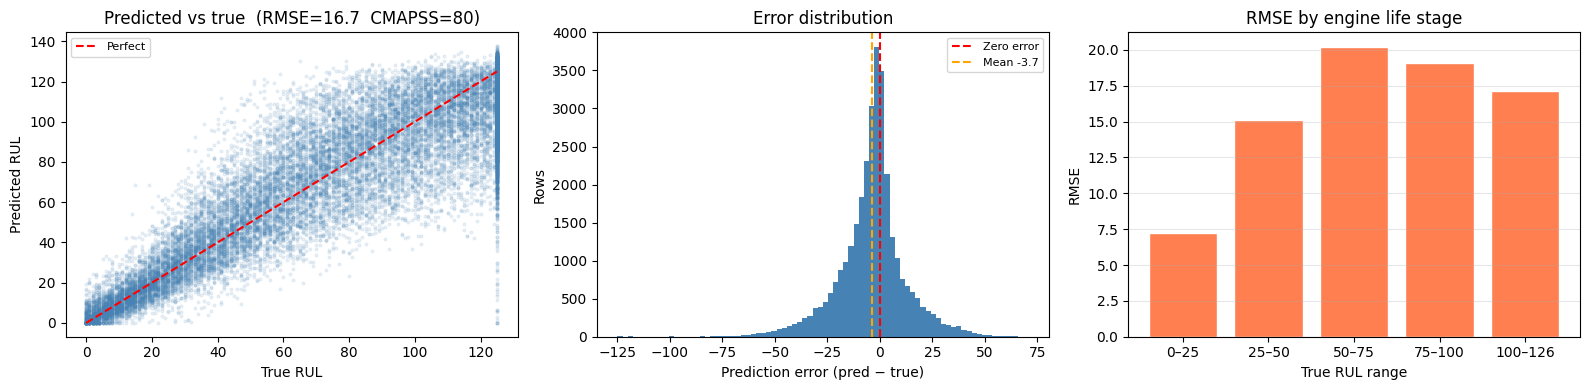

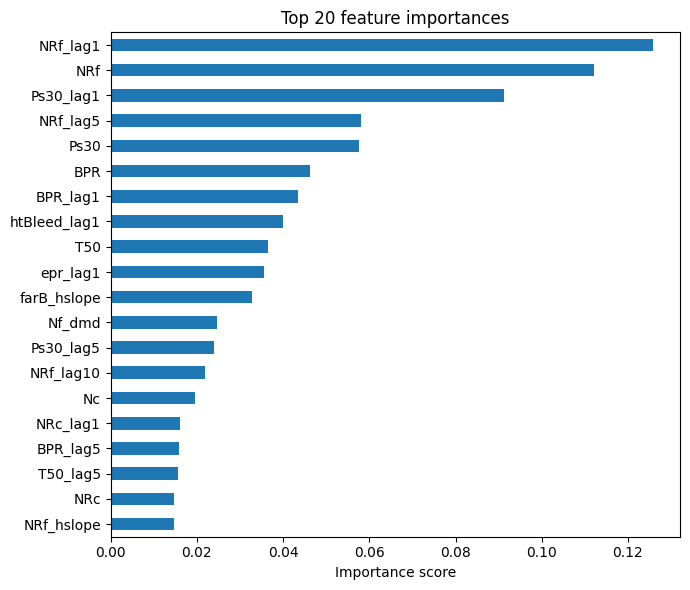

In [18]:
y_pred = reg.predict(test_df[FEATURE_COLS]).clip(0)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
err    = y_pred - y_test

# CMAPSS score: one prediction per engine (last cycle), not per row
last_test   = test_df.sort_values('Time (Cycles)').groupby('Unit Number').last().reset_index()
y_last_true = last_test['RUL'].clip(upper=RUL_CAP).values
y_last_pred = reg.predict(last_test[FEATURE_COLS]).clip(0)
score       = rul_score(y_last_true, y_last_pred)

print(f'Test RMSE       : {rmse:.2f} cycles  (all cycles, {len(test_df):,} rows)')
print(f'CMAPSS score    : {score:.1f}  (last cycle per engine, {len(last_test)} engines, lower = better)')
print(f'Mean error      : {err.mean():.2f}  (negative = conservative bias)')
print(f'Std error       : {err.std():.2f}')

print('\nRMSE + CMAPSS by RUL stage:')
buckets = [(0,25,'Near failure'),(25,50,'Late'),(50,75,'Mid'),(75,100,'Early-mid'),(100,126,'Early')]
for lo, hi, label in buckets:
    mask = (y_test >= lo) & (y_test < hi)
    if mask.sum() > 0:
        r = np.sqrt(mean_squared_error(y_test[mask], y_pred[mask]))
        s = rul_score(y_test[mask], y_pred[mask])
        print(f'  RUL {lo:>3}–{hi:<3} ({label:>12}): RMSE={r:.1f}  CMAPSS={s:.0f}  n={mask.sum():>5}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(y_test, y_pred, alpha=0.1, s=4, color='steelblue')
axes[0].plot([0, RUL_CAP], [0, RUL_CAP], 'r--', lw=1.5, label='Perfect')
axes[0].set(xlabel='True RUL', ylabel='Predicted RUL',
            title=f'Predicted vs true  (RMSE={rmse:.1f}  CMAPSS={score:.0f})')
axes[0].legend(fontsize=8)

axes[1].hist(err, bins=80, color='steelblue', edgecolor='none')
axes[1].axvline(0,          color='red',    ls='--', lw=1.5, label='Zero error')
axes[1].axvline(err.mean(), color='orange', ls='--', lw=1.5, label=f'Mean {err.mean():.1f}')
axes[1].set(xlabel='Prediction error (pred − true)', ylabel='Rows', title='Error distribution')
axes[1].legend(fontsize=8)

labels = [f'{lo}–{hi}' for lo, hi, _ in buckets]
rmses  = [np.sqrt(mean_squared_error(y_test[(y_test>=lo)&(y_test<hi)],
                                      y_pred[(y_test>=lo)&(y_test<hi)]))
          if ((y_test>=lo)&(y_test<hi)).sum() > 0 else 0
          for lo, hi, _ in buckets]
axes[2].bar(labels, rmses, color='coral', edgecolor='white')
axes[2].set(xlabel='True RUL range', ylabel='RMSE', title='RMSE by engine life stage')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

feat_imp = pd.Series(reg.feature_importances_, index=FEATURE_COLS).nlargest(20)
fig, ax = plt.subplots(figsize=(7, 6))
feat_imp.sort_values().plot(kind='barh', ax=ax)
ax.set(title='Top 20 feature importances', xlabel='Importance score')
plt.tight_layout(); plt.show()

## Deployment Simulation

Held-out training engines run to actual failure (RUL = 0), giving unambiguous outcomes.

For each engine, step through every cycle:
1. Predict — will this engine fail within `TRIGGER` cycles?
2. **Yes** → stop, record true cycles left
3. **No** → next cycle

| True RUL at alarm | Outcome |
|---|---|
| > 2 × TRIGGER | **Caught (early)** |
| TRIGGER – 2×TRIGGER | **Caught** |
| < TRIGGER | **Caught (late)** |
| alarm never fired | **Missed** |

Deployment simulation — 142 held-out engines  (TRIGGER=30)
────────────────────────────────────────────────────────────
  Caught (early) :    5 (3.5%)
  Caught         :   90 (63.4%)
  Caught (late)  :   47 (33.1%)
  Missed         :    0 (0.0%)
────────────────────────────────────────────────────────────
  In-time rate   : 66.9%
  Any catch rate : 100.0%


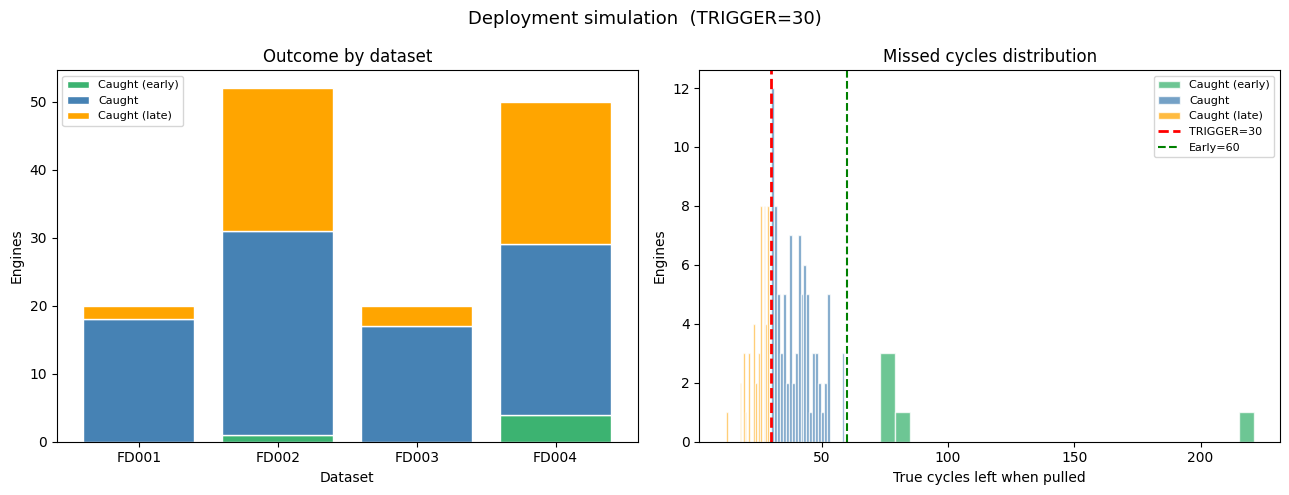

In [19]:
EARLY_THRESHOLD = 2 * TRIGGER
test_df['pred_rul'] = reg.predict(test_df[FEATURE_COLS]).clip(0)

rows = []
for unit, eng in test_df.groupby('Unit Number'):
    eng = eng.sort_values('Time (Cycles)').reset_index(drop=True)
    alarm_cycle = alarm_pred = missed_cycles = None

    for _, row in eng.iterrows():
        if row['Time (Cycles)'] < MIN_CYCLES:
            continue
        if row['pred_rul'] < TRIGGER:
            alarm_cycle   = row['Time (Cycles)']
            alarm_pred    = row['pred_rul']
            missed_cycles = max(float(row['RUL']), 0)
            break

    if alarm_cycle is not None:
        if missed_cycles > EARLY_THRESHOLD:  outcome = 'Caught (early)'
        elif missed_cycles >= TRIGGER:        outcome = 'Caught'
        else:                                 outcome = 'Caught (late)'
    else:
        outcome = 'Missed'

    rows.append({'Engine': unit, 'Dataset': eng['dataset'].iloc[0],
                 'Alarm at cycle': int(alarm_cycle) if alarm_cycle else None,
                 'Pred RUL': round(alarm_pred, 1) if alarm_pred is not None else None,
                 'Missed cycles': round(missed_cycles, 1) if missed_cycles is not None else None,
                 'Outcome': outcome})

sim = pd.DataFrame(rows)
early  = sim[sim['Outcome'] == 'Caught (early)']
caught = sim[sim['Outcome'] == 'Caught']
late   = sim[sim['Outcome'] == 'Caught (late)']
missed = sim[sim['Outcome'] == 'Missed']
n = len(sim)

print(f'Deployment simulation — {n} held-out engines  (TRIGGER={TRIGGER})')
print(f'{"─"*60}')
print(f'  Caught (early) : {len(early):>4} ({len(early)/n:.1%})')
print(f'  Caught         : {len(caught):>4} ({len(caught)/n:.1%})')
print(f'  Caught (late)  : {len(late):>4} ({len(late)/n:.1%})')
print(f'  Missed         : {len(missed):>4} ({len(missed)/n:.1%})')
print(f'{"─"*60}')
print(f'  In-time rate   : {(len(early)+len(caught))/n:.1%}')
print(f'  Any catch rate : {(n-len(missed))/n:.1%}')

outcome_order  = ['Caught (early)', 'Caught', 'Caught (late)', 'Missed']
outcome_colors = ['mediumseagreen', 'steelblue', 'orange', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Deployment simulation  (TRIGGER={TRIGGER})', fontsize=13)

datasets = sorted(sim['Dataset'].unique())
bottom = np.zeros(len(datasets))
for outcome, color in zip(outcome_order, outcome_colors):
    counts = [sim[(sim['Dataset']==d) & (sim['Outcome']==outcome)].shape[0] for d in datasets]
    if sum(counts) > 0:
        axes[0].bar(datasets, counts, bottom=bottom, color=color, label=outcome, edgecolor='white')
        bottom += np.array(counts)
axes[0].set(xlabel='Dataset', ylabel='Engines', title='Outcome by dataset')
axes[0].legend(fontsize=8)

for outcome, color in zip(['Caught (early)', 'Caught', 'Caught (late)'],
                           ['mediumseagreen', 'steelblue', 'orange']):
    subset = sim[sim['Outcome'] == outcome]['Missed cycles'].dropna()
    if len(subset) > 0:
        axes[1].hist(subset, bins=25, color=color, alpha=0.75, edgecolor='white', label=outcome)
axes[1].axvline(TRIGGER,         color='red',   ls='--', lw=2,   label=f'TRIGGER={TRIGGER}')
axes[1].axvline(EARLY_THRESHOLD, color='green', ls='--', lw=1.5, label=f'Early={EARLY_THRESHOLD}')
axes[1].set(xlabel='True cycles left when pulled', ylabel='Engines', title='Missed cycles distribution')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

## NASA Benchmark Evaluation

The official NASA test files are right-censored (sequences stop before failure). A separate RUL ground-truth file gives the true remaining life at the last observed cycle for each engine. We predict on that last cycle only.

NASA test set — 707 engines
RMSE          : 16.39 cycles
CMAPSS score  : 3559.1  (lower = better)
Mean error    : -2.31  (negative = conservative bias)
Std error     : 16.23

Per-dataset:
  FD001: RMSE=15.0  CMAPSS=351  (n=100)
  FD002: RMSE=16.0  CMAPSS=1070  (n=259)
  FD003: RMSE=13.7  CMAPSS=401  (n=100)
  FD004: RMSE=18.2  CMAPSS=1737  (n=248)


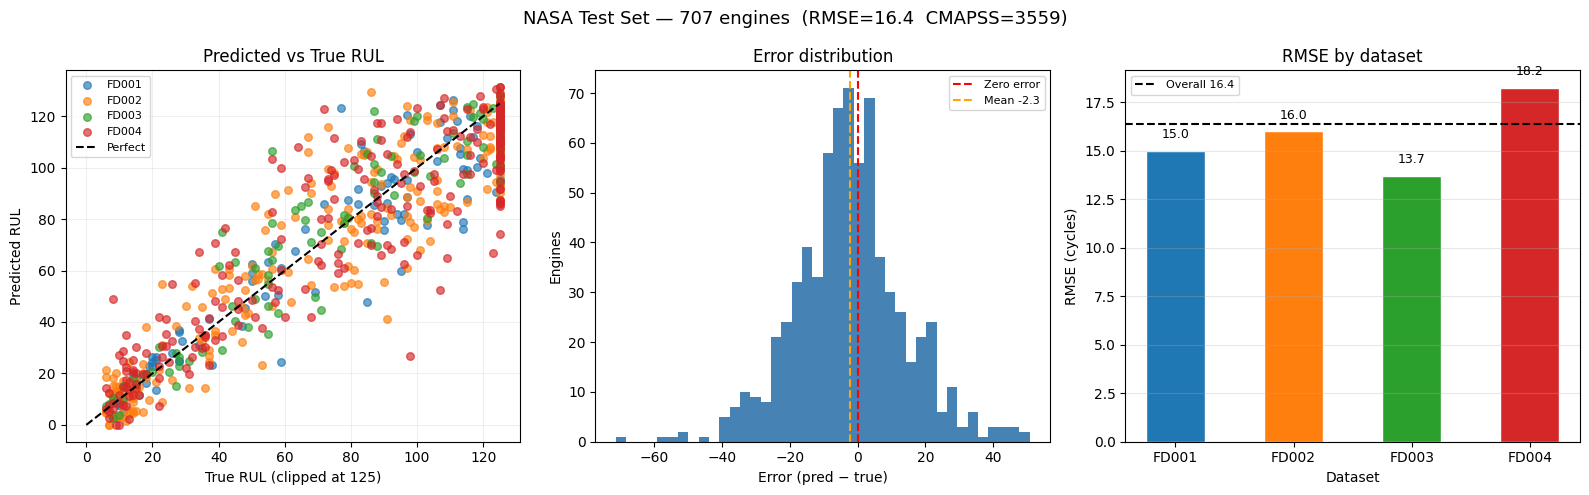

In [20]:
def engineer_features(df):
    """Apply the full feature pipeline to a new DataFrame.
    Uses pre-fit op_scaler and km — no fitting, no leakage."""
    df = df.copy()
    df['Condition'] = km.predict(op_scaler.transform(df[OP_COLS]))

    parts = []
    for unit, eng in df.groupby('Unit Number'):
        eng = eng.sort_values('Time (Cycles)').copy()
        n = len(eng)
        cumean = eng[SENSORS].expanding(min_periods=1).mean()
        frozen = cumean.iloc[min(BASELINE_N - 1, n - 1)]
        new = {f'{s}_dev': eng[s].values - np.where(np.arange(n) < BASELINE_N, cumean[s].values, frozen[s])
               for s in SENSORS}
        parts.append(pd.DataFrame(new, index=eng.index))
    feat = pd.concat(parts)
    for col in DEV_COLS: df[col] = feat[col]

    parts = []
    for unit, eng in df.groupby('Unit Number'):
        eng = eng.sort_values('Time (Cycles)').copy()
        new = {f'{s}_trend': eng[s].rolling(TREND_SMOOTH, min_periods=1).mean()
                                    .diff(TREND_WINDOW).fillna(0).values / TREND_WINDOW
               for s in SENSORS}
        parts.append(pd.DataFrame(new, index=eng.index))
    feat = pd.concat(parts)
    for col in TREND_COLS: df[col] = feat[col]

    parts = []
    for unit, eng in df.groupby('Unit Number'):
        eng = eng.sort_values('Time (Cycles)').copy()
        new = {f'{s}_hslope': (eng[s].expanding(min_periods=1).mean().values - eng[s].iloc[0])
                              / np.maximum(eng['Time (Cycles)'].values, 1)
               for s in SENSORS}
        parts.append(pd.DataFrame(new, index=eng.index))
    feat = pd.concat(parts)
    for col in HSLOPE_COLS: df[col] = feat[col]

    for num, den in RATIO_PAIRS:
        df[f'{num}_over_{den}'] = df[num] / df[den].clip(lower=1e-6)

    parts = []
    for unit, eng in df.groupby('Unit Number'):
        eng = eng.sort_values('Time (Cycles)').copy()
        new = {f'{s}_lag{lag}': eng[s].shift(lag).fillna(eng[s].iloc[0]).values
               for lag in LAG_PERIODS for s in SENSORS}
        parts.append(pd.DataFrame(new, index=eng.index))
    feat = pd.concat(parts)
    for col in LAG_COLS: df[col] = feat[col]

    return df


# ── Load NASA test files ───────────────────────────────────────────────────────
tfd001 = load_fd('test_FD001.txt'); tfd001['dataset'] = 'FD001'
tfd002 = load_fd('test_FD002.txt'); tfd002['dataset'] = 'FD002'
tfd003 = load_fd('test_FD003.txt'); tfd003['dataset'] = 'FD003'
tfd004 = load_fd('test_FD004.txt'); tfd004['dataset'] = 'FD004'

tfd002['Unit Number'] += tfd001['Unit Number'].max()
tfd003['Unit Number'] += tfd002['Unit Number'].max()
tfd004['Unit Number'] += tfd003['Unit Number'].max()

nasa_raw = pd.concat([tfd001, tfd002, tfd003, tfd004], ignore_index=True)
nasa_raw = engineer_features(nasa_raw)

# ── Ground-truth RUL files ─────────────────────────────────────────────────────
rul_arrays = {
    'FD001': pd.read_csv('../Data/RUL_FD001.txt', sep=' ', header=None)[0].values,
    'FD002': pd.read_csv('../Data/RUL_FD002.txt', sep=' ', header=None)[0].values,
    'FD003': pd.read_csv('../Data/RUL_FD003.txt', sep=' ', header=None)[0].values,
    'FD004': pd.read_csv('../Data/RUL_FD004.txt', sep=' ', header=None)[0].values,
}

# Take last observed cycle per engine
last_cycles = (nasa_raw.sort_values('Time (Cycles)')
                        .groupby('Unit Number', sort=True)
                        .last()
                        .reset_index())

# Map true RUL: engines are ordered sequentially within each dataset
rul_rows = []
for ds in ['FD001', 'FD002', 'FD003', 'FD004']:
    units = sorted(last_cycles.loc[last_cycles['dataset'] == ds, 'Unit Number'])
    for i, u in enumerate(units):
        rul_rows.append({'Unit Number': u, 'true_rul': rul_arrays[ds][i]})
last_cycles = last_cycles.merge(pd.DataFrame(rul_rows), on='Unit Number')

y_true  = last_cycles['true_rul'].clip(upper=RUL_CAP).values
y_pred  = reg.predict(last_cycles[FEATURE_COLS]).clip(0)
err     = y_pred - y_true
rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
score   = rul_score(y_true, y_pred)

print(f'NASA test set — {len(last_cycles)} engines')
print(f'RMSE          : {rmse:.2f} cycles')
print(f'CMAPSS score  : {score:.1f}  (lower = better)')
print(f'Mean error    : {err.mean():.2f}  (negative = conservative bias)')
print(f'Std error     : {err.std():.2f}')
print()
print('Per-dataset:')
for ds in ['FD001', 'FD002', 'FD003', 'FD004']:
    mask = last_cycles['dataset'] == ds
    yt = last_cycles.loc[mask, 'true_rul'].clip(upper=RUL_CAP).values
    yp = reg.predict(last_cycles.loc[mask, FEATURE_COLS]).clip(0)
    r  = np.sqrt(mean_squared_error(yt, yp))
    s  = rul_score(yt, yp)
    print(f'  {ds}: RMSE={r:.1f}  CMAPSS={s:.0f}  (n={mask.sum()})')

# ── Plots ──────────────────────────────────────────────────────────────────────
ds_colors = {'FD001': '#1f77b4', 'FD002': '#ff7f0e', 'FD003': '#2ca02c', 'FD004': '#d62728'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'NASA Test Set — {len(last_cycles)} engines  '
             f'(RMSE={rmse:.1f}  CMAPSS={score:.0f})', fontsize=13)

for ds in ['FD001', 'FD002', 'FD003', 'FD004']:
    mask = (last_cycles['dataset'] == ds).values
    axes[0].scatter(y_true[mask], y_pred[mask], alpha=0.65, s=30,
                    color=ds_colors[ds], label=ds, zorder=3)
axes[0].plot([0, RUL_CAP], [0, RUL_CAP], 'k--', lw=1.5, label='Perfect', zorder=4)
axes[0].set(xlabel='True RUL (clipped at 125)', ylabel='Predicted RUL',
            title='Predicted vs True RUL')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.2)

axes[1].hist(err, bins=40, color='steelblue', edgecolor='none')
axes[1].axvline(0,          color='red',    ls='--', lw=1.5, label='Zero error')
axes[1].axvline(err.mean(), color='orange', ls='--', lw=1.5, label=f'Mean {err.mean():.1f}')
axes[1].set(xlabel='Error (pred − true)', ylabel='Engines', title='Error distribution')
axes[1].legend(fontsize=8)

ds_labels = ['FD001', 'FD002', 'FD003', 'FD004']
ds_rmses  = []
for ds in ds_labels:
    mask = last_cycles['dataset'] == ds
    yt = last_cycles.loc[mask, 'true_rul'].clip(upper=RUL_CAP).values
    yp = reg.predict(last_cycles.loc[mask, FEATURE_COLS]).clip(0)
    ds_rmses.append(np.sqrt(mean_squared_error(yt, yp)))
bars = axes[2].bar(ds_labels, ds_rmses, color=[ds_colors[d] for d in ds_labels],
                   edgecolor='white', width=0.5)
axes[2].axhline(rmse, color='black', ls='--', lw=1.5, label=f'Overall {rmse:.1f}')
for bar, val in zip(bars, ds_rmses):
    axes[2].text(bar.get_x() + bar.get_width() / 2, val + 0.5, f'{val:.1f}',
                 ha='center', va='bottom', fontsize=9)
axes[2].set(xlabel='Dataset', ylabel='RMSE (cycles)', title='RMSE by dataset')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

True RUL at last observed cycle (NASA test set, 707 engines):
  Min    : 6
  Median : 83
  Mean   : 81.4
  Max    : 195

  RUL <= TRIGGER (30)          : 159 engines  (22.5%)
  RUL <= 2×TRIGGER (60)       : 273 engines  (38.6%)
  RUL >  2×TRIGGER                   : 434 engines  (61.4%)

Per dataset:
  FD001: min=7  median=86  max=145  (RUL≤30: 25/100)
  FD002: min=6  median=80  max=194  (RUL≤30: 61/259)
  FD003: min=6  median=78  max=145  (RUL≤30: 20/100)
  FD004: min=6  median=88  max=195  (RUL≤30: 53/248)


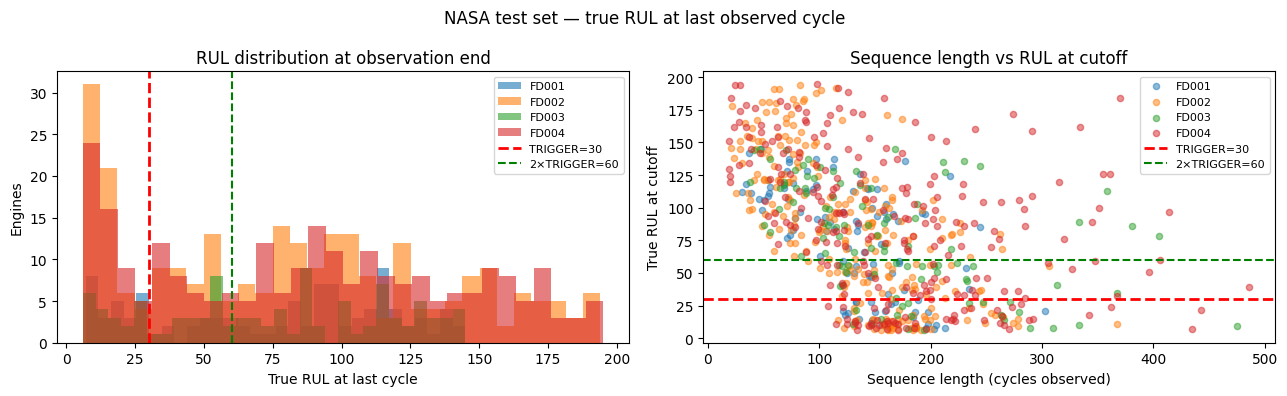

In [21]:
# How far from failure are the NASA test engines when their sequence ends?
rul_vals = last_cycles['true_rul'].values

print(f'True RUL at last observed cycle (NASA test set, {len(rul_vals)} engines):')
print(f'  Min    : {rul_vals.min():.0f}')
print(f'  Median : {np.median(rul_vals):.0f}')
print(f'  Mean   : {rul_vals.mean():.1f}')
print(f'  Max    : {rul_vals.max():.0f}')
print()
print(f'  RUL <= TRIGGER ({TRIGGER})          : {(rul_vals <= TRIGGER).sum()} engines  ({(rul_vals <= TRIGGER).mean():.1%})')
print(f'  RUL <= 2×TRIGGER ({2*TRIGGER})       : {(rul_vals <= 2*TRIGGER).sum()} engines  ({(rul_vals <= 2*TRIGGER).mean():.1%})')
print(f'  RUL >  2×TRIGGER                   : {(rul_vals > 2*TRIGGER).sum()} engines  ({(rul_vals > 2*TRIGGER).mean():.1%})')
print()
print('Per dataset:')
for ds in ['FD001', 'FD002', 'FD003', 'FD004']:
    v = last_cycles.loc[last_cycles['dataset'] == ds, 'true_rul'].values
    print(f'  {ds}: min={v.min():.0f}  median={np.median(v):.0f}  max={v.max():.0f}  '
          f'(RUL≤{TRIGGER}: {(v<=TRIGGER).sum()}/{len(v)})')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('NASA test set — true RUL at last observed cycle', fontsize=12)

ds_colors = {'FD001': '#1f77b4', 'FD002': '#ff7f0e', 'FD003': '#2ca02c', 'FD004': '#d62728'}
for ds in ['FD001', 'FD002', 'FD003', 'FD004']:
    v = last_cycles.loc[last_cycles['dataset'] == ds, 'true_rul'].values
    axes[0].hist(v, bins=30, alpha=0.6, color=ds_colors[ds], edgecolor='none', label=ds)
axes[0].axvline(TRIGGER,       color='red',   ls='--', lw=2,   label=f'TRIGGER={TRIGGER}')
axes[0].axvline(2 * TRIGGER,   color='green', ls='--', lw=1.5, label=f'2×TRIGGER={2*TRIGGER}')
axes[0].set(xlabel='True RUL at last cycle', ylabel='Engines', title='RUL distribution at observation end')
axes[0].legend(fontsize=8)

# Sequence length vs true RUL at cutoff
seq_len = nasa_raw.groupby('Unit Number')['Time (Cycles)'].max().reset_index()
seq_len.columns = ['Unit Number', 'seq_len']
lc_plot = last_cycles.merge(seq_len, on='Unit Number')
for ds in ['FD001', 'FD002', 'FD003', 'FD004']:
    m = lc_plot['dataset'] == ds
    axes[1].scatter(lc_plot.loc[m, 'seq_len'], lc_plot.loc[m, 'true_rul'],
                    alpha=0.5, s=20, color=ds_colors[ds], label=ds)
axes[1].axhline(TRIGGER,     color='red',   ls='--', lw=2,   label=f'TRIGGER={TRIGGER}')
axes[1].axhline(2 * TRIGGER, color='green', ls='--', lw=1.5, label=f'2×TRIGGER={2*TRIGGER}')
axes[1].set(xlabel='Sequence length (cycles observed)', ylabel='True RUL at cutoff',
            title='Sequence length vs RUL at cutoff')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## NASA Test — Deployment Simulation

NASA test sequences are right-censored (they stop before failure). We reconstruct the true RUL at every observed cycle as `true_rul_at_T = rul_file + (T_max − T)`, then run the same alarm logic.

**"Missed"** here means the alarm never fired within the observed window. It is less definitive than a miss on run-to-failure data: the engine still had life remaining when observation ended.

NASA deployment simulation — 707 engines  (TRIGGER=30)
────────────────────────────────────────────────────────────
  Caught (early) :   12 (1.7%)
  Caught         :  125 (17.7%)
  Caught (late)  :   53 (7.5%)
  Missed         :  517 (73.1%)
────────────────────────────────────────────────────────────
  In-time rate   : 19.4%
  Any catch rate : 26.9%


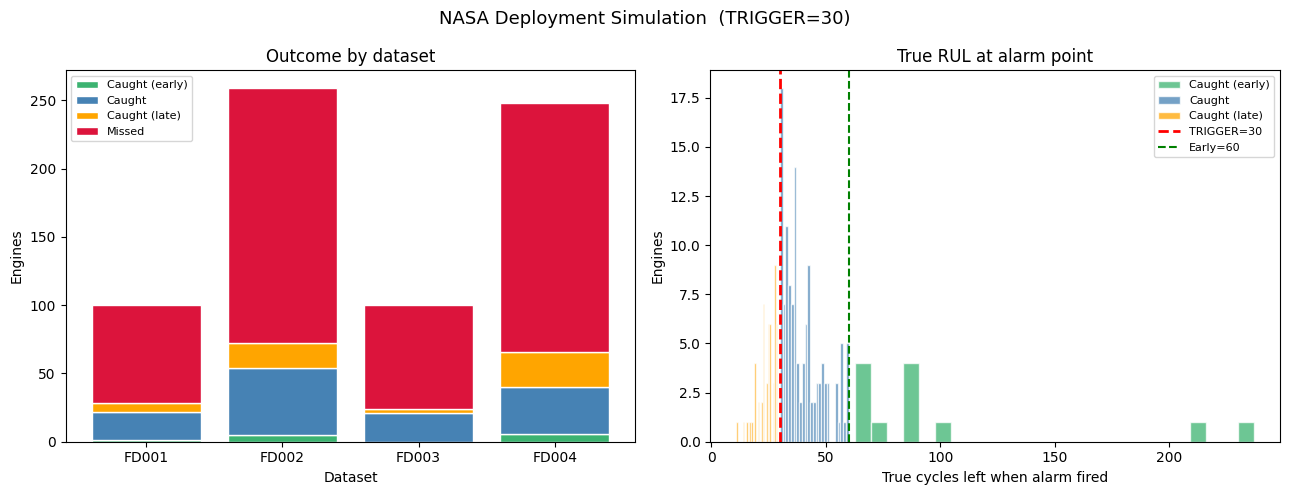

In [22]:
# Reconstruct true RUL for every cycle:
#   true_rul_at_T = rul_at_last_cycle + (T_max - T)
unit_last_cycle = nasa_raw.groupby('Unit Number')['Time (Cycles)'].max()
unit_true_rul   = last_cycles.set_index('Unit Number')['true_rul']  # unclipped

nasa_raw['true_rul_cycle'] = (
    nasa_raw['Unit Number'].map(unit_true_rul) +
    nasa_raw['Unit Number'].map(unit_last_cycle) -
    nasa_raw['Time (Cycles)']
)
nasa_raw['pred_rul'] = reg.predict(nasa_raw[FEATURE_COLS]).clip(0)

EARLY_THRESHOLD = 2 * TRIGGER

rows = []
for unit, eng in nasa_raw.groupby('Unit Number'):
    eng = eng.sort_values('Time (Cycles)').reset_index(drop=True)
    alarm_cycle = alarm_pred = true_rul_at_alarm = None

    for _, row in eng.iterrows():
        if row['Time (Cycles)'] < MIN_CYCLES:
            continue
        if row['pred_rul'] < TRIGGER:
            alarm_cycle       = row['Time (Cycles)']
            alarm_pred        = row['pred_rul']
            true_rul_at_alarm = row['true_rul_cycle']
            break

    if alarm_cycle is not None:
        if true_rul_at_alarm > EARLY_THRESHOLD:  outcome = 'Caught (early)'
        elif true_rul_at_alarm >= TRIGGER:        outcome = 'Caught'
        else:                                     outcome = 'Caught (late)'
    else:
        outcome = 'Missed'

    rows.append({
        'Engine':            unit,
        'Dataset':           eng['dataset'].iloc[0],
        'Alarm at cycle':    int(alarm_cycle) if alarm_cycle is not None else None,
        'Pred RUL':          round(alarm_pred, 1) if alarm_pred is not None else None,
        'True RUL at alarm': round(true_rul_at_alarm, 1) if true_rul_at_alarm is not None else None,
        'Outcome':           outcome,
    })

sim_nasa = pd.DataFrame(rows)
early  = sim_nasa[sim_nasa['Outcome'] == 'Caught (early)']
caught = sim_nasa[sim_nasa['Outcome'] == 'Caught']
late   = sim_nasa[sim_nasa['Outcome'] == 'Caught (late)']
missed = sim_nasa[sim_nasa['Outcome'] == 'Missed']
n = len(sim_nasa)

print(f'NASA deployment simulation — {n} engines  (TRIGGER={TRIGGER})')
print(f'{"─"*60}')
print(f'  Caught (early) : {len(early):>4} ({len(early)/n:.1%})')
print(f'  Caught         : {len(caught):>4} ({len(caught)/n:.1%})')
print(f'  Caught (late)  : {len(late):>4} ({len(late)/n:.1%})')
print(f'  Missed         : {len(missed):>4} ({len(missed)/n:.1%})')
print(f'{"─"*60}')
print(f'  In-time rate   : {(len(early)+len(caught))/n:.1%}')
print(f'  Any catch rate : {(n-len(missed))/n:.1%}')

outcome_order  = ['Caught (early)', 'Caught', 'Caught (late)', 'Missed']
outcome_colors = ['mediumseagreen', 'steelblue', 'orange', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'NASA Deployment Simulation  (TRIGGER={TRIGGER})', fontsize=13)

datasets = sorted(sim_nasa['Dataset'].unique())
bottom = np.zeros(len(datasets))
for outcome, color in zip(outcome_order, outcome_colors):
    counts = [sim_nasa[(sim_nasa['Dataset'] == d) & (sim_nasa['Outcome'] == outcome)].shape[0]
              for d in datasets]
    if sum(counts) > 0:
        axes[0].bar(datasets, counts, bottom=bottom, color=color, label=outcome, edgecolor='white')
        bottom += np.array(counts)
axes[0].set(xlabel='Dataset', ylabel='Engines', title='Outcome by dataset')
axes[0].legend(fontsize=8)

for outcome, color in zip(['Caught (early)', 'Caught', 'Caught (late)'],
                           ['mediumseagreen', 'steelblue', 'orange']):
    subset = sim_nasa[sim_nasa['Outcome'] == outcome]['True RUL at alarm'].dropna()
    if len(subset) > 0:
        axes[1].hist(subset, bins=25, color=color, alpha=0.75, edgecolor='white', label=outcome)
axes[1].axvline(TRIGGER,         color='red',   ls='--', lw=2,   label=f'TRIGGER={TRIGGER}')
axes[1].axvline(EARLY_THRESHOLD, color='green', ls='--', lw=1.5, label=f'Early={EARLY_THRESHOLD}')
axes[1].set(xlabel='True cycles left when alarm fired', ylabel='Engines',
            title='True RUL at alarm point')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()